# Практическое занятие 3. Дерево решений для классификации режимов электропривода Версия преподавателя

## Назначение занятия

Цель занятия - построить интерпретируемую модель, которая аппроксимирует
учебное инженерное правило допустимости режима электропривода.

Классификация (classification) - задача машинного обучения, в которой модель
относит наблюдение к одному из заранее заданных классов. В данной работе
целевая переменная `is_allowed` принимает два значения: 1 - режим допустим,
0 - режим недопустим. Важно понимать, что классы сформированы по заданным
учебным порогам тока, температуры, скорости, КПД и момента; дерево решений
учится воспроизводить это инженерное правило по измеряемым признакам.


## Теоретические сведения

Дерево решений (Decision Tree) последовательно разбивает пространство признаков
на области с помощью условий вида `feature <= threshold`, где `feature` -
признак, а `threshold` - порог. Узел (node) содержит условие разбиения, лист
(leaf) содержит итоговое решение модели, глубина (depth) показывает число
условий на пути от корня дерева до листа. Преимущество дерева решений -
интерпретируемость: результат можно представить как набор правил.

Внутри дерева используется критерий неоднородности узла. В данном занятии
применяется индекс Джини (Gini impurity). Для узла с долями классов `p_k`
он записывается так:

```text
Gini = 1 - sum(p_k^2)
```

Если в узле находятся объекты только одного класса, индекс Джини равен 0.
Если классы перемешаны, значение индекса больше. Обучение дерева выбирает
разделения, которые сильнее уменьшают неоднородность дочерних узлов.

Переобучение (overfitting) - ситуация, когда модель слишком точно подстроилась
под обучающую выборку и хуже работает на новых данных. Для дерева решений
риск переобучения уменьшают ограничением глубины `max_depth` и минимального
числа наблюдений в листе `min_samples_leaf`.


## Как дерево решений строит классификационную модель

Дерево решений является жадным алгоритмом (greedy algorithm). Это означает,
что на каждом шаге модель выбирает локально лучшее разбиение текущего узла,
не перебирая все возможные деревья целиком. Для каждого признака и каждого
кандидатного порога проверяется условие вида

```text
feature <= threshold
```

После такого условия наблюдения делятся на левую и правую дочерние группы.
Качество разбиения оценивается по уменьшению неоднородности. Если используется
индекс Джини, взвешенная неоднородность после разбиения равна

$$G_{split} =
\frac{n_L}{n}G_L + \frac{n_R}{n}G_R,$$

где `n_L` и `n_R` - числа наблюдений в левом и правом дочерних узлах,
`G_L` и `G_R` - индексы Джини в этих узлах. Модель выбирает разбиение, при
котором значение `G_split` минимально, то есть классы в дочерних узлах
становятся более однородными.

В листе дерева прогнозируется класс большинства среди обучающих наблюдений,
попавших в этот лист. Для нового наблюдения модель последовательно проверяет
условия от корня до листа. Этот путь называется путем решения (decision path).
Именно поэтому дерево решений можно интерпретировать как набор правил:

```text
если условие 1 выполнено и условие 2 выполнено, то прогнозируется класс A
```

Вероятность класса в листе обычно оценивается как доля объектов этого класса
среди обучающих наблюдений листа. Например, если в листе 18 допустимых и
2 недопустимых режима, оценка вероятности допустимого режима равна 18 / 20.
Такая вероятность является эмпирической, то есть рассчитанной по данным, и
не должна трактоваться как нормативная вероятность безопасности оборудования.

Ограничения дерева решений:

1. дерево строит прямоугольные области в пространстве признаков, поэтому
   гладкие физические зависимости описываются ступенчато;
2. небольшие изменения данных могут изменить структуру дерева;
3. слишком глубокое дерево склонно запоминать частные особенности выборки;
4. важность признаков показывает вклад в разбиения, но не доказывает
   физическую причинность.


## Источники и проверка актуальности

1. ElectricMotorTemperature, Zenodo TSML Archive - открытый набор многомерных временных рядов для регрессии температуры электродвигателя. Используется как реальный ориентир структуры временных признаков. URL: https://zenodo.org/records/11235562
2. IEC 60034-1:2026. Rotating electrical machines - Part 1: Rating and performance. Используется как нормативный ориентир терминологии вращающихся электрических машин. URL: https://webstore.iec.ch/en/publication/89961
3. IEC 60034-2-1:2024. Rotating electrical machines - Part 2-1: Standard methods for determining losses and efficiency from tests. Используется как нормативный ориентир по потерям и КПД. URL: https://webstore.iec.ch/en/publication/67756
4. Документация pandas по пропущенным данным. URL: https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html
5. Документация scikit-learn по моделям, разбиению данных и метрикам качества. URL: https://scikit-learn.org/stable/

Дата проверки актуальности ссылок: 2026-05-07.


## Рекомендуемые реальные наборы данных для занятия 3

Для дерева решений особенно полезны наборы, где класс режима или состояния
можно объяснить через физически интерпретируемые признаки: ток, температура,
вибрация, скорость, момент, нагрузка.

1. Paderborn University Bearing Data Center. URL:
   https://mb.uni-paderborn.de/en/kat/research/bearing-datacenter.
   Реальные данные стенда
   электромеханического привода: синхронно измеренные токи двигателя,
   вибрации, скорость, момент, радиальная нагрузка и температура. Классы:
   исправные и поврежденные подшипники. Применение: классификация состояния
   и извлечение простых статистических признаков из сигналов. Ограничение:
   лицензия CC BY-NC 4.0, коммерческое использование запрещено без отдельного
   согласования.
2. Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating
   Machine, Mendeley Data. URL:
   https://data.mendeley.com/datasets/ztmf3m7h5x/6. Реальные данные вращающейся машины при нормальном
   состоянии, дефектах подшипников, несоосности и дисбалансе ротора.
   Применение: бинарная или многоклассовая классификация после расчета
   признаков по временным сигналам. Ограничение: исходные файлы требуют
   предварительного чтения форматов MAT и TDMS.
3. MOTOR FAULT DETECTION DATA, Figshare. URL:
   https://figshare.com/articles/dataset/MOTOR_FAULT_DETECTION_DATA/27216219.
   Набор по трехфазному асинхронному
   двигателю с синхронными сигналами вибрации, тока и напряжения, организован
   в CSV-файлы для исправных и неисправных режимов. Применение: удобная
   база для дерева решений после агрегации сигналов по окнам. Ограничение:
   общий объем около 5 ГБ, для аудиторного занятия нужна малая выборка.
4. Case Western Reserve University Bearing Data Center. URL:
   https://engineering.case.edu/bearingdatacenter/welcome. Классический
   эталонный сравнительный набор данных (benchmark dataset) по диагностике дефектов
   подшипников электродвигателя. Применение: демонстрация классификации
   нормального и поврежденного состояния. Ограничение: данные представлены
   как вибрационные сигналы, поэтому для начинающих нужна готовая процедура
   извлечения признаков.

Методическое решение для эталонного занятия: использовать компактный учебный
CSV с заранее рассчитанными признаками, а реальные наборы применять на
следующем уровне после освоения дерева решений.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


# Поиск корня учебного проекта.
# Если блокнот запускается из корня репозитория, Path.cwd() уже указывает
# на нужный каталог. Если блокнот открыт из папки notebooks/student или
# notebooks/teacher, проверяются родительские каталоги.
candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]

PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src").exists() and (candidate / "data").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError(
        "Не найден корень проекта. Запустите блокнот из каталога appai_lab "
        "или укажите путь к проекту вручную."
    )

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


DATA_DIR = PROJECT_ROOT / "data" / "processed"
DATA_FILE = DATA_DIR / "practice_03_drive_mode_features.csv"
DIAGNOSTICS_FILE = DATA_DIR / "practice_03_drive_mode_diagnostics.csv"
CATALOG_FILE = DATA_DIR / "practice_01_03_dataset_catalog.csv"
ASSIGNMENTS_FILE = DATA_DIR / "practice_01_03_dataset_assignments.csv"

if not DATA_FILE.exists() or not CATALOG_FILE.exists() or not ASSIGNMENTS_FILE.exists() or (DIAGNOSTICS_FILE is not None and not DIAGNOSTICS_FILE.exists()):
    raise FileNotFoundError(
        "Не найдены учебные CSV-файлы. Выполните из корня проекта команду "
        "`python scripts/generate_datasets.py`, затем повторно запустите блокнот."
    )

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

RANDOM_STATE = 20260507


def draw_process_diagram(labels, title):
    """Построить простую схему последовательности этапов работы.

    Схема используется как учебная визуализация. Она не является алгоритмом,
    а показывает логическую структуру анализа: от источника данных к выводу.
    """
    fig, ax = plt.subplots(figsize=(max(10, 2.2 * len(labels)), 2.3))
    ax.set_axis_off()
    x_positions = np.linspace(0.06, 0.94, len(labels))

    for index, (x_pos, label) in enumerate(zip(x_positions, labels)):
        box = FancyBboxPatch(
            (x_pos - 0.075, 0.40),
            0.15,
            0.28,
            boxstyle="round,pad=0.02",
            linewidth=1.2,
            edgecolor="black",
            facecolor="#e8f1f8",
            transform=ax.transAxes,
        )
        ax.add_patch(box)
        ax.text(
            x_pos,
            0.54,
            label,
            ha="center",
            va="center",
            fontsize=10,
            wrap=True,
            transform=ax.transAxes,
        )
        if index < len(labels) - 1:
            arrow = FancyArrowPatch(
                (x_pos + 0.085, 0.54),
                (x_positions[index + 1] - 0.085, 0.54),
                arrowstyle="->",
                mutation_scale=12,
                linewidth=1.1,
                color="black",
                transform=ax.transAxes,
            )
            ax.add_patch(arrow)

    ax.set_title(title, fontsize=13, pad=14)
    plt.show()


def plot_correlation_heatmap(data, columns, title):
    """Построить тепловую карту корреляций без дополнительных библиотек."""
    corr = data[columns].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(columns)))
    ax.set_yticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=45, ha="right")
    ax.set_yticklabels(columns)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="Коэффициент корреляции")

    for i in range(len(columns)):
        for j in range(len(columns)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

DATA_FILE


PosixPath('/mnt/f/projects/appai_lab/data/processed/practice_03_drive_mode_features.csv')

## Логическая схема классификации режимов

В классификационной задаче сначала определяется инженерное правило, по
которому режим считается допустимым или недопустимым. Затем это правило
превращается в целевую переменную. Модель не должна получать в качестве
признаков прямое описание этого правила, иначе возникнет утечка данных.


## Последовательность подготовки данных и использования классификационной модели

Классификация режимов отличается от регрессии тем, что модель прогнозирует не
числовую величину, а класс. Класс - заранее заданная категория состояния
объекта. В данном занятии классы имеют инженерный смысл: допустимый и
недопустимый режим электропривода.

Рекомендуемая последовательность действий:

1. Определить инженерные ограничения: предельный ток, предельную температуру,
   предельную скорость, минимальный КПД и предельный момент.
2. Сформировать целевую переменную `is_allowed`: `1` - допустимый режим,
   `0` - недопустимый режим. Правило формирования класса должно быть
   записано явно.
3. Проверить распределение классов. Если один класс встречается редко, доля
   правильных ответов может быть недостаточной метрикой качества.
4. Исключить признаки, прямо раскрывающие ответ: `mode_label`,
   `violation_count`, признаки причин нарушений и запасы до ограничений.
5. Выбрать входные признаки, которые могли бы быть доступны в реальной
   системе мониторинга до расчета диагностических показателей: ток,
   напряжение, скорость, момент и температура.
6. Разделить данные на обучающую и тестовую выборки с сохранением долей
   классов. Такое разбиение называется стратифицированным
   (stratified split).
7. Построить базовую модель большинства (majority baseline), которая всегда
   прогнозирует самый частый класс. Она задает минимальный ориентир качества.
8. Обучить дерево решений с ограниченной глубиной. Ограничение глубины
   повышает интерпретируемость и уменьшает риск переобучения.
9. Рассчитать метрики отдельно для класса `0` и класса `1`. Для безопасности
   особенно важна полнота обнаружения недопустимых режимов.
10. Построить матрицу ошибок и отдельно посчитать долю ложных разрешений,
    когда истинно недопустимый режим ошибочно признан допустимым.
11. Выписать правила дерева решений в инженерной форме и проверить, не
    противоречат ли они физическому смыслу объекта.
12. Оценить влияние параметра `max_depth`: слишком малая глубина дает
    недообучение, слишком большая глубина может привести к переобучению.

При использовании обученного дерева для нового режима измеренные признаки
последовательно проходят через условия дерева от корня к листу. Итоговый лист
задает прогноз класса. Такой прогноз следует рассматривать как
информационную поддержку инженерного решения, а не как самостоятельное
нормативное разрешение эксплуатации оборудования.


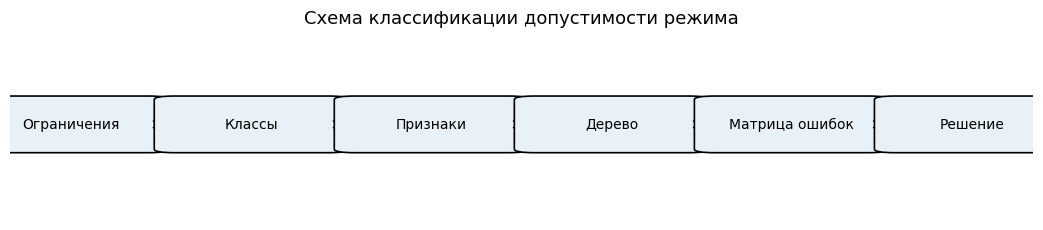

In [2]:
draw_process_diagram(
    [
        "Ограничения",
        "Классы",
        "Признаки",
        "Дерево",
        "Матрица ошибок",
        "Решение",
    ],
    "Схема классификации допустимости режима",
)


In [3]:
df = pd.read_csv(DATA_FILE)
diagnostics_df = pd.read_csv(DIAGNOSTICS_FILE)
full_df = df.merge(diagnostics_df, on="sample_id", how="left", validate="one_to_one")

print(f"Размер таблицы: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()


Размер таблицы: 420 строк, 9 столбцов


,sample_id,profile_id,speed_rpm,torque_nm,voltage_v,current_a,ambient_temp_c,temperature_c,is_allowed
0,1,2,22596.6,0.06250,23.982,7.8264,33.391,43.876,1
1,2,1,8000.0,0.05202,49.125,1.2864,20.120,47.263,1
2,3,6,58000.0,0.02216,48.636,3.7452,28.202,44.100,1
3,4,1,9062.2,0.05789,23.472,3.0100,29.910,56.853,1
4,5,1,8000.0,0.05648,60.378,1.0483,22.277,40.255,1


## Реконструкция целевого правила

Перед обучением классификатора необходимо понять, как сформирована целевая
переменная. В учебном наборе `is_allowed` является результатом инженерного
правила: режим допустим только тогда, когда не нарушены ограничения по току,
температуре, скорости, КПД и моменту. Такая постановка полезна для обучения
интерпретации дерева решений, но она не означает, что модель самостоятельно
открывает новый физический закон.

Реконструкция правила нужна для контроля утечки данных. Если в признаки
включить столбцы, которые прямо являются частями правила, дерево будет
воспроизводить заданную разметку, а не решать независимую прогностическую
задачу.


In [4]:
target_rule_table = pd.DataFrame(
    [
        {
            "condition": "overcurrent",
            "engineering_meaning": "ток выше учебного предела",
            "class_effect": "делает режим недопустимым",
        },
        {
            "condition": "overheating",
            "engineering_meaning": "температура выше учебного предела",
            "class_effect": "делает режим недопустимым",
        },
        {
            "condition": "overspeed",
            "engineering_meaning": "скорость выше учебного предела",
            "class_effect": "делает режим недопустимым",
        },
        {
            "condition": "low_efficiency",
            "engineering_meaning": "КПД ниже учебного предела",
            "class_effect": "делает режим недопустимым",
        },
        {
            "condition": "torque_violation",
            "engineering_meaning": "момент выше учебного ограничения для режима",
            "class_effect": "делает режим недопустимым",
        },
    ]
)

rule_reconstructed_is_allowed = (
    full_df[["overcurrent", "overheating", "overspeed", "low_efficiency", "torque_violation"]]
    .sum(axis=1)
    .eq(0)
    .astype(int)
)

print(
    "Число расхождений между is_allowed и восстановленным правилом:",
    int((full_df["is_allowed"] != rule_reconstructed_is_allowed).sum()),
)
target_rule_table


Число расхождений между is_allowed и восстановленным правилом: 0


,condition,engineering_meaning,class_effect
0,overcurrent,ток выше учебного предела,делает режим недопустимым
1,overheating,температура выше учебного предела,делает режим недопустимым
2,overspeed,скорость выше учебного предела,делает режим недопустимым
3,low_efficiency,КПД ниже учебного предела,делает режим недопустимым
4,torque_violation,момент выше учебного ограничения для режима,делает режим недопустимым


## Структура классификационного набора данных

В учебном наборе каждая строка соответствует одному режиму работы. Целевая
переменная `is_allowed` задает бинарный класс: 1 - допустимый режим, 0 -
недопустимый режим. Дополнительный столбец `mode_label` содержит приоритетную
инженерную причину ограничения. Если в строке есть несколько нарушений,
показывается только первая причина в принятом порядке приоритетов, а полное
число нарушений хранится в столбце `violation_count`. Столбцы причин
нарушений и запасов до пределов нельзя использовать как входные признаки,
поскольку они напрямую раскрывают целевой класс.


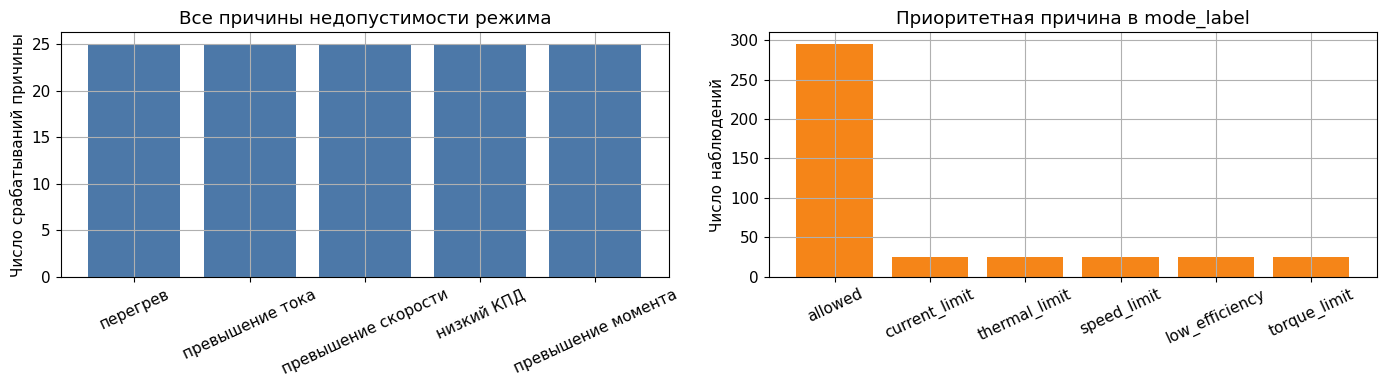

,all_reason_count,label_ru
overheating,25,перегрев
overcurrent,25,превышение тока
overspeed,25,превышение скорости
low_efficiency,25,низкий КПД
torque_violation,25,превышение момента


In [5]:
violation_columns = [
    "overheating",
    "overcurrent",
    "overspeed",
    "low_efficiency",
    "torque_violation",
]
violation_labels = {
    "overheating": "перегрев",
    "overcurrent": "превышение тока",
    "overspeed": "превышение скорости",
    "low_efficiency": "низкий КПД",
    "torque_violation": "превышение момента",
}

reason_counts = full_df[violation_columns].sum().sort_values(ascending=False)
primary_mode_counts = full_df["mode_label"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(
    [violation_labels[column] for column in reason_counts.index],
    reason_counts.values,
    color="#4c78a8",
)
axes[0].set_ylabel("Число срабатываний причины")
axes[0].set_title("Все причины недопустимости режима")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(primary_mode_counts.index, primary_mode_counts.values, color="#f58518")
axes[1].set_ylabel("Число наблюдений")
axes[1].set_title("Приоритетная причина в mode_label")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        "all_reason_count": reason_counts,
        "label_ru": [violation_labels[column] for column in reason_counts.index],
    }
)


## Проверка распределения классов

Перед обучением классификатора необходимо проверить, сколько наблюдений
относится к каждому классу. Сильный дисбаланс классов может привести к
формально высокой точности при плохом обнаружении редкого класса.


In [6]:
class_counts = df["is_allowed"].value_counts().sort_index()
class_counts.rename(index={0: "недопустимый режим", 1: "допустимый режим"})


is_allowed
недопустимый режим    125
допустимый режим      295
Name: count, dtype: int64

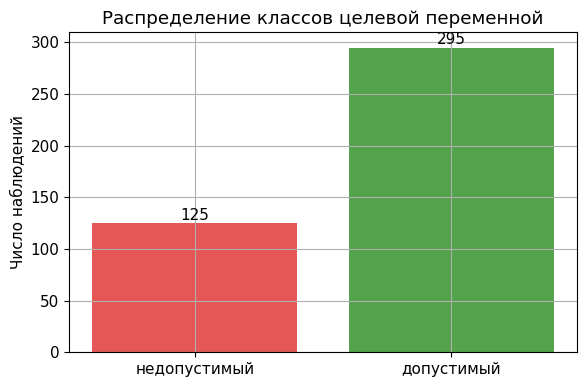

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["недопустимый", "допустимый"]
ax.bar(labels, class_counts.values, color=["#e45756", "#54a24b"])
ax.set_ylabel("Число наблюдений")
ax.set_title("Распределение классов целевой переменной")

for index, value in enumerate(class_counts.values):
    ax.text(index, value + 3, str(value), ha="center")

plt.tight_layout()
plt.show()


## Выбор признаков и исключение утечки данных

Столбец `mode_label` объясняет причину ограничения режима и не должен
использоваться как входной признак. Столбцы с запасами до ограничений также
исключаются из базовой модели, поскольку они прямо построены из пороговых
правил.


## Строгая прогностическая постановка и демонстрация утечки

Если признак входит в правило формирования целевого класса, его использование
меняет смысл задачи. В базовой модели этого занятия используются только
строгие признаки: скорость, момент, напряжение, ток, температура окружающей
среды и температура объекта. Столбцы `efficiency`, `output_power_w`,
`mode_label`, `violation_count` и запасы до ограничений исключены.

Отдельный раздел ниже показывает демонстрацию утечки данных: при включении
`efficiency` и `output_power_w` дерево решений получает расчетные величины,
близкие к правилу разметки, и качество становится методически завышенным.
Этот результат нельзя считать качеством базовой модели.

В отчете необходимо явно указать выбранную постановку. Для диагностической
постановки допустимо использовать `efficiency`, но нельзя утверждать, что
модель обнаружила независимый физический закон.


In [8]:
feature_audit = pd.DataFrame(
    [
        {
            "column": "speed_rpm",
            "feature_type": "измеряемый признак",
            "baseline_use": "используется в строгой модели",
            "strict_use": "используется",
            "risk": "участвует в правиле через overspeed; допустим только при явном указании диагностической постановки",
        },
        {
            "column": "torque_nm",
            "feature_type": "измеряемый признак",
            "baseline_use": "используется в строгой модели",
            "strict_use": "используется",
            "risk": "участвует в оценке перегрузки по моменту",
        },
        {
            "column": "voltage_v",
            "feature_type": "измеряемый признак",
            "baseline_use": "используется в строгой модели",
            "strict_use": "используется",
            "risk": "прямого раскрытия класса нет",
        },
        {
            "column": "current_a",
            "feature_type": "измеряемый признак",
            "baseline_use": "используется в строгой модели",
            "strict_use": "используется",
            "risk": "участвует в правиле через overcurrent",
        },
        {
            "column": "temperature_c",
            "feature_type": "измеряемый признак",
            "baseline_use": "используется в строгой модели",
            "strict_use": "используется",
            "risk": "участвует в правиле через overheating",
        },
        {
            "column": "output_power_w",
            "feature_type": "расчетный признак",
            "baseline_use": "исключается",
            "strict_use": "исключается",
            "risk": "связан с КПД и энергетическим балансом",
        },
        {
            "column": "efficiency",
            "feature_type": "расчетный признак",
            "baseline_use": "исключается",
            "strict_use": "исключается",
            "risk": "прямо участвует в правиле low_efficiency",
        },
        {
            "column": "mode_label, violation_count, current_margin_a, temperature_margin_c, speed_margin_rpm, overcurrent, overheating, overspeed, low_efficiency, torque_violation",
            "feature_type": "служебные признаки правила",
            "baseline_use": "исключаются",
            "strict_use": "исключаются",
            "risk": "прямо раскрывают целевую переменную",
        },
    ]
)

feature_audit


,column,feature_type,baseline_use,strict_use,risk
0,speed_rpm,измеряемый признак,используется в строгой модели,используется,участвует в правиле через overspeed; допустим ...
1,torque_nm,измеряемый признак,используется в строгой модели,используется,участвует в оценке перегрузки по моменту
2,voltage_v,измеряемый признак,используется в строгой модели,используется,прямого раскрытия класса нет
3,current_a,измеряемый признак,используется в строгой модели,используется,участвует в правиле через overcurrent
4,temperature_c,измеряемый признак,используется в строгой модели,используется,участвует в правиле через overheating
5,output_power_w,расчетный признак,исключается,исключается,связан с КПД и энергетическим балансом
6,efficiency,расчетный признак,исключается,исключается,прямо участвует в правиле low_efficiency
7,"mode_label, violation_count, current_margin_a,...",служебные признаки правила,исключаются,исключаются,прямо раскрывают целевую переменную


In [9]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree


feature_columns = ['speed_rpm', 'torque_nm', 'voltage_v', 'current_a', 'ambient_temp_c', 'temperature_c']
target_column = "is_allowed"

X = df[feature_columns]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)


Обучающая выборка: (315, 6)
Тестовая выборка: (105, 6)


## Базовая модель классификации

Перед обучением дерева решений необходимо задать простой ориентир качества.
Базовая модель большинства всегда предсказывает класс, который чаще встречался
в обучающей выборке. Такая модель не использует инженерные признаки, поэтому
дерево решений должно превосходить ее не только по общей точности, но и по
полноте обнаружения критически важных классов.


In [10]:
def classification_metrics_dict(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    cm_local = confusion_matrix(y_true, y_pred, labels=[0, 1])
    not_allowed_total = cm_local[0].sum()
    dangerous_false_allowed_rate = (
        cm_local[0, 1] / not_allowed_total if not_allowed_total > 0 else 0.0
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_not_allowed": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_not_allowed": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_not_allowed": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "precision_allowed": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_allowed": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_allowed": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "dangerous_false_allowed_rate": dangerous_false_allowed_rate,
    }


majority_class = int(y_train.mode().iloc[0])
baseline_pred = np.full(shape=len(y_test), fill_value=majority_class, dtype=int)

pd.Series(
    classification_metrics_dict(y_test, baseline_pred),
    name="majority_baseline",
).to_frame("value")


,value
accuracy,0.704762
precision_not_allowed,0.000000
recall_not_allowed,0.000000
f1_not_allowed,0.000000
precision_allowed,0.704762
recall_allowed,1.000000
f1_allowed,0.826816
dangerous_false_allowed_rate,1.000000


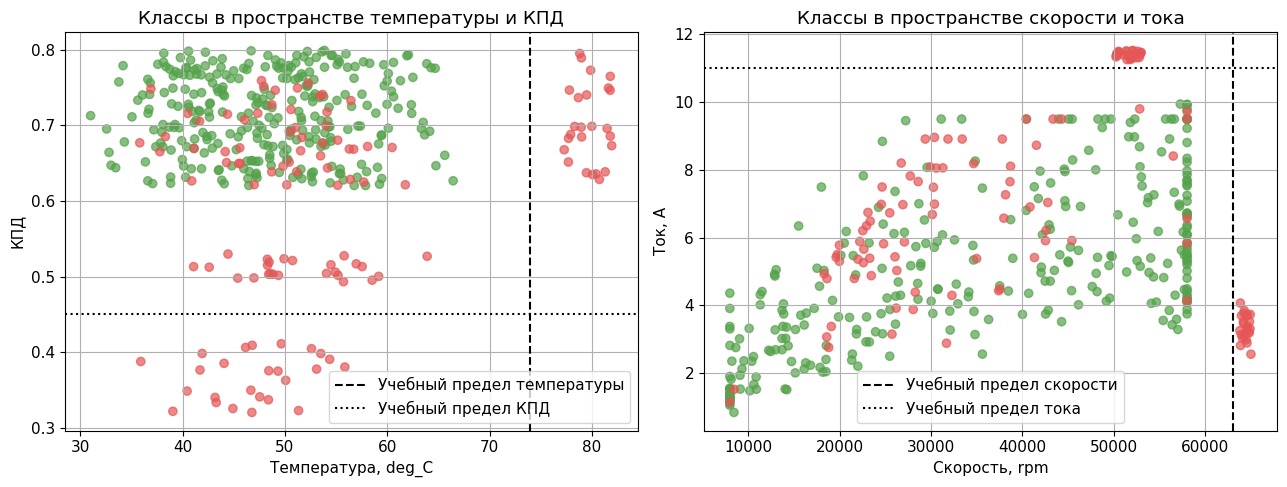

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = df["is_allowed"].map({0: "#e45756", 1: "#54a24b"})

axes[0].scatter(full_df["temperature_c"], full_df["efficiency"], c=colors, alpha=0.70)
axes[0].axvline(74.0, color="black", linestyle="--", label="Учебный предел температуры")
axes[0].axhline(0.45, color="black", linestyle=":", label="Учебный предел КПД")
axes[0].set_xlabel("Температура, deg_C")
axes[0].set_ylabel("КПД")
axes[0].set_title("Классы в пространстве температуры и КПД")
axes[0].legend()

axes[1].scatter(df["speed_rpm"], df["current_a"], c=colors, alpha=0.70)
axes[1].axvline(63000.0, color="black", linestyle="--", label="Учебный предел скорости")
axes[1].axhline(11.0, color="black", linestyle=":", label="Учебный предел тока")
axes[1].set_xlabel("Скорость, rpm")
axes[1].set_ylabel("Ток, A")
axes[1].set_title("Классы в пространстве скорости и тока")
axes[1].legend()

plt.tight_layout()
plt.show()


## Обучение дерева решений

Параметр `max_depth=3` ограничивает число последовательных правил. Это делает
модель проще для интерпретации и снижает риск переобучения.


In [12]:
tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=8,
    random_state=RANDOM_STATE,
)

tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)


## Демонстрация утечки данных

Ниже строится дополнительное дерево решений с признаками `efficiency` и
`output_power_w`. Эта модель не является базовой: она показывает, как
расчетные величины, близкие к правилу разметки, искусственно завышают метрики.
Такой результат следует интерпретировать как пример утечки данных
(data leakage), а не как доказательство высокой прогностической способности.


In [13]:
leakage_demo_columns = [
    "speed_rpm",
    "torque_nm",
    "voltage_v",
    "current_a",
    "ambient_temp_c",
    "temperature_c",
    "efficiency",
    "output_power_w",
]

leakage_X = full_df[leakage_demo_columns]
leakage_X_train = leakage_X.loc[X_train.index]
leakage_X_test = leakage_X.loc[X_test.index]

leakage_tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=8,
    random_state=RANDOM_STATE,
)

leakage_tree_model.fit(leakage_X_train, y_train)
leakage_pred = leakage_tree_model.predict(leakage_X_test)


## Метрики классификации

Доля правильных ответов (accuracy) - доля верно классифицированных наблюдений
среди всех наблюдений. Точность положительных предсказаний (precision)
показывает, какая доля объектов, отнесенных моделью к выбранному
положительному классу, действительно принадлежит этому классу. Полнота
(recall) показывает, какая доля объектов выбранного положительного класса
найдена моделью. F1-мера (F1-score) является гармоническим средним precision
и recall.

Для инженерной безопасности отдельно анализируется класс 0, то есть
недопустимый режим. Наиболее опасная ошибка - ложное разрешение: истинный
класс 0, прогноз 1.

$accuracy = (TP + TN)/(TP + TN + FP + FN)$,

$precision = TP/(TP + FP)$,

$recall = TP/(TP + FN)$,

$F1 = 2 \cdot precision \cdot recall/(precision + recall)$.

Здесь TP - истинно положительные решения, TN - истинно отрицательные решения,
FP - ложноположительные решения, FN - ложноотрицательные решения. Смысл этих
обозначений зависит от того, какой класс выбран положительным.


## Приоритет метрик для инженерной безопасности

В задачах контроля режима метрики должны интерпретироваться с учетом
последствий ошибки. Для класса "недопустимый режим" основное значение имеет
полнота (recall), поскольку она показывает, какая доля действительно
недопустимых режимов обнаружена моделью.

Показатель `dangerous_false_allowed_rate` отдельно фиксирует долю случаев,
когда недопустимый режим ошибочно признан допустимым. Если общая доля
правильных ответов высока, но полнота для недопустимого класса низка, модель
не должна рассматриваться как приемлемая для инженерного контроля.


In [14]:
classification_metrics_df = pd.DataFrame(
    [
        {
            "model": "majority_baseline",
            **classification_metrics_dict(y_test, baseline_pred),
        },
        {
            "model": "strict_decision_tree",
            **classification_metrics_dict(y_test, y_pred),
        },
        {
            "model": "leakage_demo_decision_tree",
            **classification_metrics_dict(y_test, leakage_pred),
        },
    ]
).set_index("model")

classification_metrics_df


,accuracy,precision_not_allowed,recall_not_allowed,f1_not_allowed,precision_allowed,recall_allowed,f1_allowed,dangerous_false_allowed_rate
model,,,,,,,,
majority_baseline,0.704762,0.000000,0.000000,0.000000,0.704762,1.000000,0.826816,1.000000
strict_decision_tree,0.933333,0.961538,0.806452,0.877193,0.924051,0.986486,0.954248,0.193548
leakage_demo_decision_tree,0.942857,0.962963,0.838710,0.896552,0.935897,0.986486,0.960526,0.161290


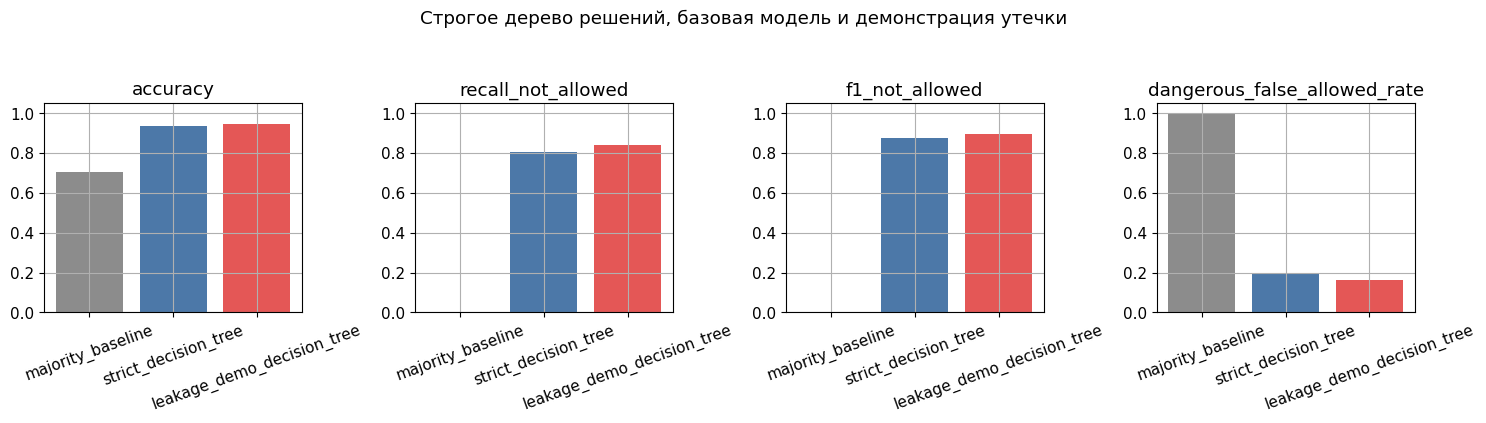

In [15]:
selected_classification_metrics = [
    "accuracy",
    "recall_not_allowed",
    "f1_not_allowed",
    "dangerous_false_allowed_rate",
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, metric in zip(axes, selected_classification_metrics):
    ax.bar(
        classification_metrics_df.index,
        classification_metrics_df[metric],
        color=["#8c8c8c", "#4c78a8", "#e45756"],
    )
    ax.set_ylim(0.0, 1.05)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Строгое дерево решений, базовая модель и демонстрация утечки", y=1.05)
plt.tight_layout()
plt.show()


In [16]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["недопустимый режим", "допустимый режим"],
))


                    precision    recall  f1-score   support

недопустимый режим       0.96      0.81      0.88        31
  допустимый режим       0.92      0.99      0.95        74

          accuracy                           0.93       105
         macro avg       0.94      0.90      0.92       105
      weighted avg       0.94      0.93      0.93       105



## Матрица ошибок

Матрица ошибок (confusion matrix) показывает число правильных и неправильных
решений по каждому классу. Для инженерной диагностики особенно важно
обсуждать ошибки, при которых недопустимый режим ошибочно признается
допустимым.


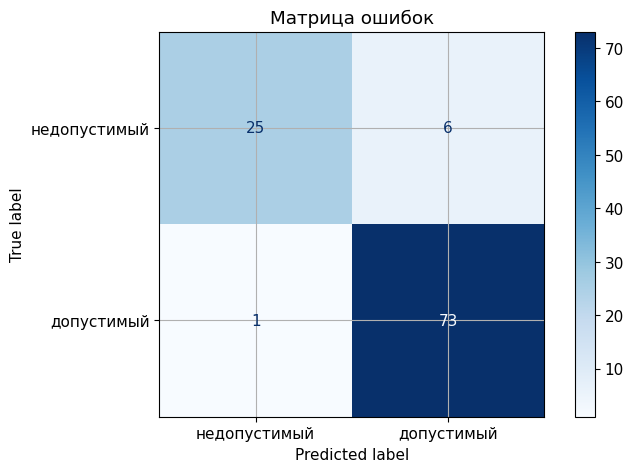

In [17]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["недопустимый", "допустимый"],
)
disp.plot(values_format="d", cmap="Blues")
plt.title("Матрица ошибок")
plt.show()


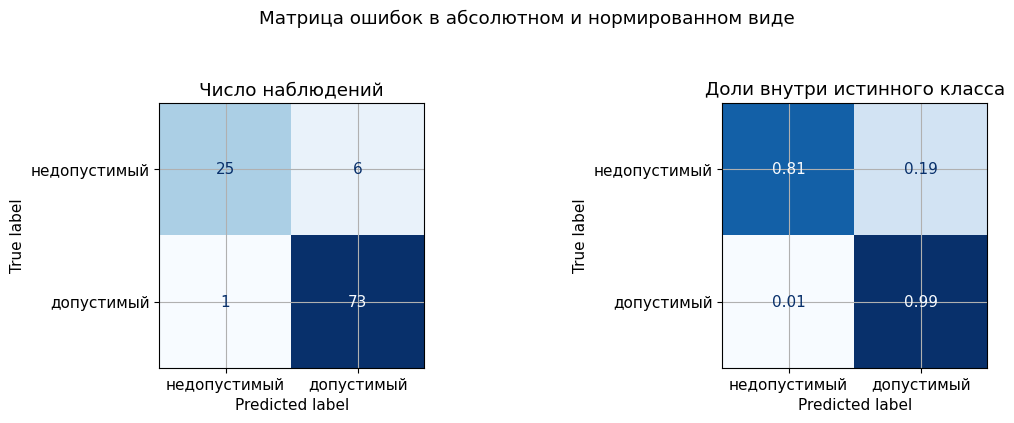

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_count = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_normalized = confusion_matrix(y_test, y_pred, labels=[0, 1], normalize="true")
display_labels = ["недопустимый", "допустимый"]

ConfusionMatrixDisplay(
    confusion_matrix=cm_count,
    display_labels=display_labels,
).plot(values_format="d", cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Число наблюдений")

ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=display_labels,
).plot(values_format=".2f", cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Доли внутри истинного класса")

plt.suptitle("Матрица ошибок в абсолютном и нормированном виде", y=1.05)
plt.tight_layout()
plt.show()


In [19]:
dangerous_error_mask = (y_test == 0) & (y_pred == 1)
dangerous_errors = X_test.loc[dangerous_error_mask].copy()
dangerous_errors["true_class"] = y_test.loc[dangerous_error_mask]
dangerous_errors["predicted_class"] = y_pred[dangerous_error_mask.to_numpy()]
dangerous_indices = y_test.index[dangerous_error_mask]
diagnostic_columns_for_errors = [
    "sample_id",
    "mode_label",
    "overcurrent",
    "overheating",
    "overspeed",
    "low_efficiency",
    "torque_violation",
    "violation_count",
]
dangerous_diagnostics = full_df.loc[dangerous_indices, diagnostic_columns_for_errors]
dangerous_errors = dangerous_diagnostics.join(dangerous_errors)

print(
    "Число опасных ошибок, при которых недопустимый режим признан допустимым:",
    len(dangerous_errors),
)
dangerous_errors.head()


Число опасных ошибок, при которых недопустимый режим признан допустимым: 6


,sample_id,mode_label,overcurrent,overheating,overspeed,low_efficiency,torque_violation,violation_count,speed_rpm,torque_nm,voltage_v,current_a,ambient_temp_c,temperature_c,true_class,predicted_class
339,340,thermal_limit,0,1,0,0,0,1,58000.0,0.03040,59.778,4.1376,21.336,77.804,0,1
381,382,low_efficiency,0,0,0,1,0,1,37395.8,0.02733,60.617,4.4318,26.121,41.915,0,1
378,379,low_efficiency,0,0,0,1,0,1,28051.9,0.02546,59.931,3.8767,25.596,39.050,0,1
387,388,low_efficiency,0,0,0,1,0,1,37530.3,0.02281,59.982,4.4804,25.774,43.284,0,1
371,372,low_efficiency,0,0,0,1,0,1,38148.4,0.03404,48.576,7.2645,20.042,44.053,0,1


## Информационная полнота признаков

Информационная полнота признакового пространства означает, что выбранные
признаки содержат достаточно сведений для различения всех важных классов. В
строгой модели занятия 3 намеренно исключены `efficiency` и `output_power_w`,
поскольку они прямо раскрывают правило `low_efficiency`. Это защищает модель
от утечки данных, но одновременно ухудшает обнаружение части режимов с низким
КПД.

Следующая таблица показывает, какие причины недопустимости модель пропускает
чаще всего. Если recall для `low_efficiency` мал, это не является ошибкой
библиотеки или дерева решений. Это следствие компромисса между защитой от
утечки данных и разрешающей способностью признакового пространства.


In [20]:
test_error_analysis = full_df.loc[y_test.index, diagnostic_columns_for_errors].copy()
test_error_analysis["true_class"] = y_test
test_error_analysis["predicted_class"] = y_pred

not_allowed_by_mode = (
    test_error_analysis[test_error_analysis["true_class"] == 0]
    .groupby("mode_label")
    .agg(
        test_count=("mode_label", "size"),
        missed_as_allowed=("predicted_class", lambda values: int((values == 1).sum())),
    )
)
not_allowed_by_mode["recall_not_allowed"] = (
    1.0 - not_allowed_by_mode["missed_as_allowed"] / not_allowed_by_mode["test_count"]
)
not_allowed_by_mode.sort_values(["recall_not_allowed", "test_count"], ascending=[True, False])


,test_count,missed_as_allowed,recall_not_allowed
mode_label,,,
low_efficiency,5,5,0.000000
thermal_limit,7,1,0.857143
speed_limit,8,0,1.000000
current_limit,7,0,1.000000
torque_limit,4,0,1.000000


## Интерпретация дерева

Важность признака в дереве решений показывает, насколько признак участвовал в
уменьшении неоднородности классов. Этот показатель полезен как ориентир, но
не является доказательством физической причинности.


## Интерпретация правил дерева решений

Правило дерева решений (decision rule) следует переводить в инженерную форму:
указать признак, порог, направление неравенства и физический смысл условия.
Например, порог по температуре должен интерпретироваться как ограничение
теплового состояния, а не как абстрактное числовое разделение.

Важность признаков (feature importance) отражает вклад признака в уменьшение
неоднородности узлов. Этот показатель зависит от обучающей выборки, выбранной
глубины дерева и набора признаков. Поэтому он является средством
интерпретации модели, но не доказательством причинной связи.


In [21]:
feature_importance = (
    pd.Series(tree_model.feature_importances_, index=feature_columns)
    .sort_values(ascending=False)
)
feature_importance


voltage_v         0.312956
temperature_c     0.277853
speed_rpm         0.191368
current_a         0.168071
torque_nm         0.049751
ambient_temp_c    0.000000
dtype: float64

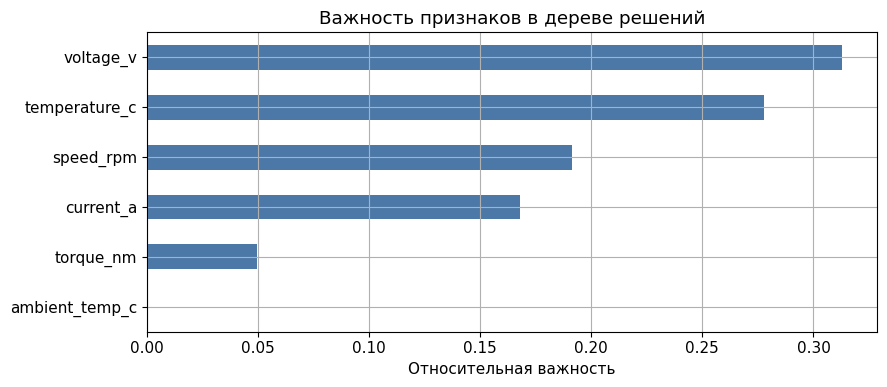

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
feature_importance.sort_values().plot(kind="barh", ax=ax, color="#4c78a8")
ax.set_xlabel("Относительная важность")
ax.set_title("Важность признаков в дереве решений")
plt.tight_layout()
plt.show()


## Влияние глубины дерева

Глубина дерева определяет максимальное число последовательных условий от
корня до листа. Малое значение может привести к недообучению: модель слишком
груба и не описывает важные разделения. Слишком большая глубина может привести
к переобучению: модель запоминает частные особенности обучающей выборки.


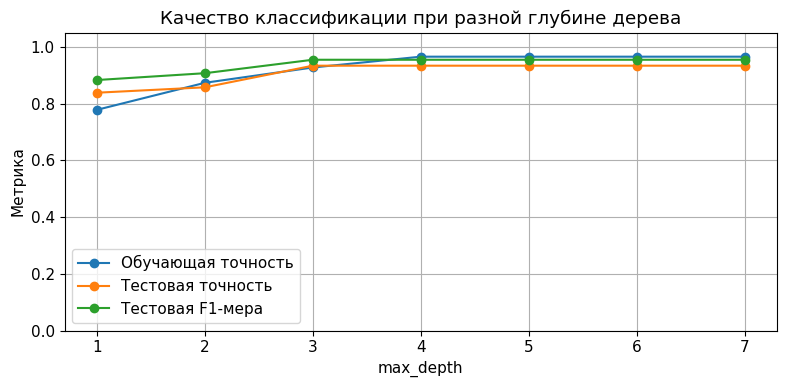

,max_depth,train_accuracy,test_accuracy,test_f1_allowed
0,1,0.777778,0.838095,0.882759
1,2,0.873016,0.857143,0.906832
2,3,0.926984,0.933333,0.954248
3,4,0.965079,0.933333,0.954248
4,5,0.965079,0.933333,0.954248
5,6,0.965079,0.933333,0.954248
6,7,0.965079,0.933333,0.954248


In [23]:
depth_rows = []

for depth in range(1, 8):
    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=8,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    depth_rows.append(
        {
            "max_depth": depth,
            "train_accuracy": accuracy_score(y_train, train_pred),
            "test_accuracy": accuracy_score(y_test, test_pred),
            "test_f1_allowed": f1_score(y_test, test_pred, zero_division=0),
        }
    )

depth_df = pd.DataFrame(depth_rows)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depth_df["max_depth"], depth_df["train_accuracy"], marker="o", label="Обучающая точность")
ax.plot(depth_df["max_depth"], depth_df["test_accuracy"], marker="o", label="Тестовая точность")
ax.plot(depth_df["max_depth"], depth_df["test_f1_allowed"], marker="o", label="Тестовая F1-мера")
ax.set_xlabel("max_depth")
ax.set_ylabel("Метрика")
ax.set_ylim(0.0, 1.05)
ax.set_title("Качество классификации при разной глубине дерева")
ax.legend()
plt.tight_layout()
plt.show()

depth_df


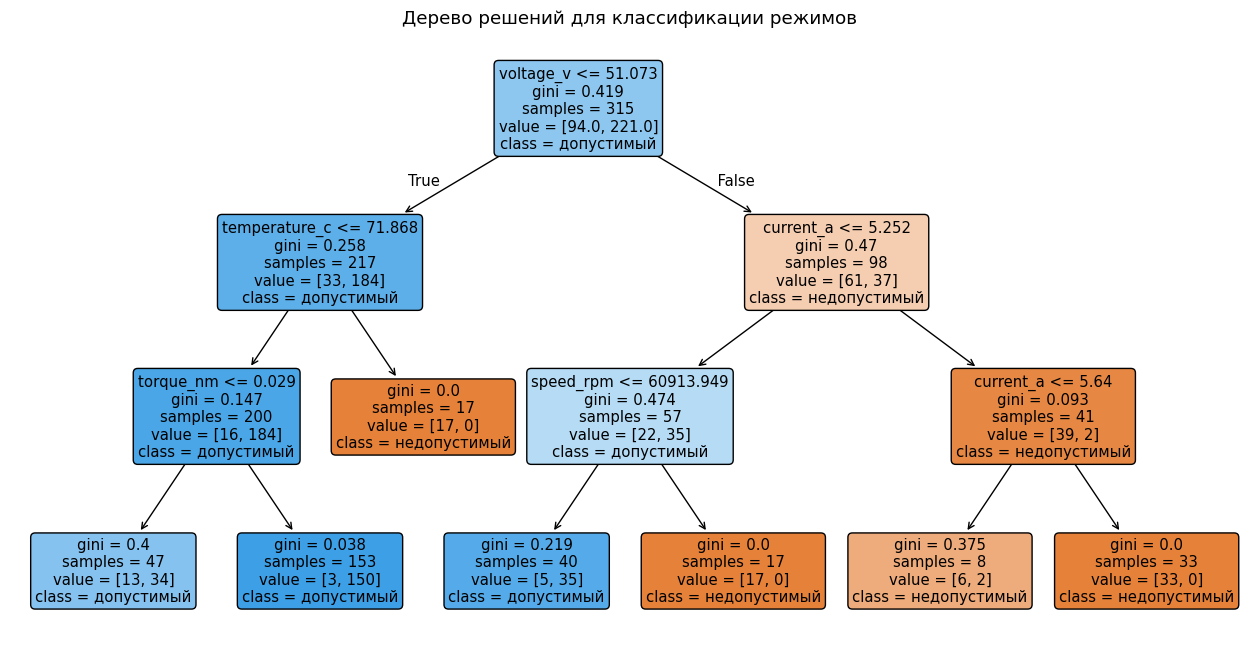

In [24]:
plt.figure(figsize=(16, 8))
plot_tree(
    tree_model,
    feature_names=feature_columns,
    class_names=["недопустимый", "допустимый"],
    filled=True,
    rounded=True,
    impurity=True,
)
plt.title("Дерево решений для классификации режимов")
plt.show()


## Упрощенная карта решений по двум признакам

Для объяснения логики классификации полезно рассмотреть только два признака.
Такая модель хуже полной модели, но ее решение можно изобразить на плоскости.
Цвет фона показывает, какой класс дерево присваивает области признакового
пространства.


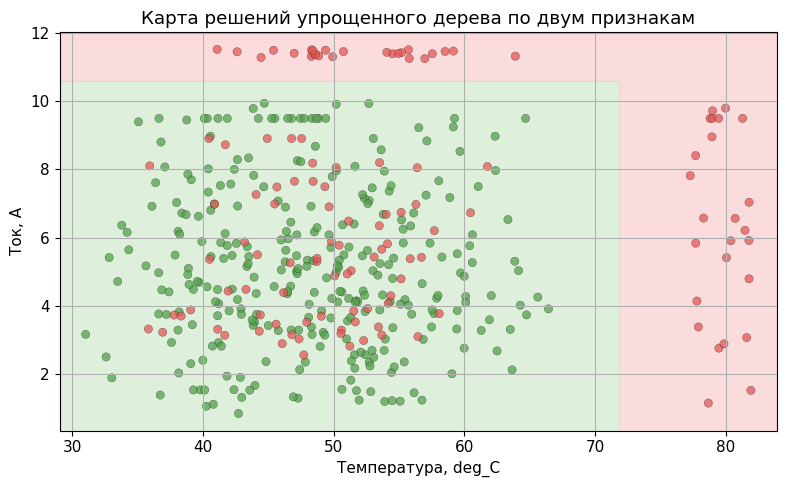

In [25]:
two_feature_columns = ["temperature_c", "current_a"]
two_feature_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=8,
    random_state=RANDOM_STATE,
)
two_feature_tree.fit(X_train[two_feature_columns], y_train)

x_min, x_max = df["temperature_c"].min() - 2, df["temperature_c"].max() + 2
y_min, y_max = df["current_a"].min() - 0.5, df["current_a"].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 240),
    np.linspace(y_min, y_max, 240),
)
grid = pd.DataFrame(
    {
        "temperature_c": xx.ravel(),
        "current_a": yy.ravel(),
    }
)
zz = two_feature_tree.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 5))
ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], colors=["#f3b2b0", "#b7dfb2"], alpha=0.45)
ax.scatter(df["temperature_c"], df["current_a"], c=colors, edgecolor="black", linewidth=0.2, alpha=0.75)
ax.set_xlabel("Температура, deg_C")
ax.set_ylabel("Ток, A")
ax.set_title("Карта решений упрощенного дерева по двум признакам")
plt.tight_layout()
plt.show()


## Задание для аудиторного отчета

1. Укажите целевую переменную и признаки.
2. Приведите распределение классов.
3. Приведите значения accuracy, precision, recall и F1 отдельно для класса
   "недопустимый режим" и класса "допустимый режим".
4. Вставьте матрицу ошибок и объясните наиболее опасный тип ошибки.
5. Сформулируйте 2-3 правила дерева решений в инженерной форме.
6. Рассчитайте долю ложных разрешений:
   `dangerous_false_allowed_rate = cm[0, 1] / sum(cm[0, :])`.
7. Измените `max_depth` и объясните, как меняется качество модели.
8. Укажите, почему данное занятие является аппроксимацией инженерного правила,
   а не доказательством нового физического закона.

Ответ группы:


In [26]:
# Самостоятельный эксперимент.
# Измените max_depth и сравните результаты с базовой моделью.
experiment_depth = 3

experiment_tree = DecisionTreeClassifier(
    max_depth=experiment_depth,
    min_samples_leaf=8,
    random_state=RANDOM_STATE,
)
experiment_tree.fit(X_train, y_train)
experiment_pred = experiment_tree.predict(X_test)

pd.Series(
    classification_metrics_dict(y_test, experiment_pred),
    name="experiment",
)


accuracy                        0.933333
precision_not_allowed           0.961538
recall_not_allowed              0.806452
f1_not_allowed                  0.877193
precision_allowed               0.924051
recall_allowed                  0.986486
f1_allowed                      0.954248
dangerous_false_allowed_rate    0.193548
Name: experiment, dtype: float64

## Реестр найденных наборов данных и развернутые задания

В этом блокноте используются все найденные источники данных через единый
реестр. Реестр не загружает крупные внешние архивы автоматически. Он задает
отдельные расширенные задания, которые можно выполнять после базовой части
занятия.

Каждое задание включает:

1. теоретический блок - какие понятия и ограничения нужно объяснить;
2. практический блок - какие действия выполнить в Jupyter Notebook;
3. ожидаемые артефакты - какие таблицы, графики и выводы должны быть в отчете;
4. риски - какие ограничения источника необходимо учесть.

Ниже показаны все найденные наборы данных, а затем задания, относящиеся к
занятию 3.


In [27]:
dataset_catalog = pd.read_csv(CATALOG_FILE)
dataset_assignments = pd.read_csv(ASSIGNMENTS_FILE)

pd.set_option("display.max_colwidth", 120)

all_datasets_view = dataset_catalog[
    [
        "dataset_id",
        "name",
        "object",
        "license",
        "access",
        "size_note",
        "lessons",
        "risk_level",
        "implementation_status",
    ]
]
all_datasets_view


,dataset_id,name,object,license,access,size_note,lessons,risk_level,implementation_status
0,zenodo_motor_temperature,ElectricMotorTemperature,"электродвигатель, представленный многомерными временными рядами (multivariate time series)",CC BY 4.0,прямая загрузка Zenodo,"TRAIN около 104 МБ, TEST около 45 МБ; фрагменты длиной 60 отсчетов","1,2,3",средний,external_notebook_ready
1,pmsm_inverter_fault_zenodo,Comprehensive Dataset for Fault Detection and Diagnosis in Inverter-Driven PMSM Systems,"PMSM-инвертор, лабораторная диагностика",CC BY 4.0,прямая загрузка Zenodo,компактный архив около 1.1 МБ по данным карточки источника,"1,2,3",низкий,external_notebook_ready
2,ev_powertrain_efficiency,Processed Data for EV Powertrain Efficiency,электропривод транспортного средства,CC BY 4.0,Mendeley Data,размер на карточке не указан,"1,2",средний,external_notebook_ready
3,system_identification_electric_motor,Identifying the Physics Behind an Electric Motor,PMSM и двухуровневый IGBT-инвертор,Data files copyright original authors; условия переиздания неясны,Kaggle,около 40 млн образцов,"1,2",высокий,methodology_only
4,ipmsm_motor_parameters,Dataset for motor parameters of IPMSM,параметры и геометрия синхронного двигателя с внутренним расположением постоянных магнитов (Interior Permanent Magne...,CC BY-SA 4.0,Kaggle,CSV и изображения геометрии,"1,2",средний,methodology_only
5,pmsm_foc_mendeley,PMSM_FOC dataset,PMSM с Field Oriented Control,CC BY 4.0,Mendeley Data,размер на карточке не указан,"1,2,3",средний,methodology_only
6,permanent_magnet_dc_worm_motor,Permanent Magnet DC Worm Geared Motor Data,двигатель постоянного тока с червячным редуктором,CC BY 4.0,Mendeley Data,около 27 МБ по статье Data in Brief,"1,2,3",средний,methodology_only
7,uci_ai4i_2020,AI4I 2020 Predictive Maintenance Dataset,синтетическая промышленная установка,CC BY 4.0,прямой UCI-доступ без регистрации,"10 000 строк, 14 столбцов, около 510 КБ","1,3",низкий,methodology_only
8,figshare_three_phase_induction_fault,MOTOR FAULT DETECTION DATA,трехфазный асинхронный двигатель,CC BY 4.0,прямая загрузка Figshare,"около 5.16 ГБ, 10 CSV-файлов","1,3",высокий,methodology_only
9,paderborn_bearing,Paderborn University Bearing Data Center,электромеханический привод с подшипниковыми дефектами,CC BY-NC 4.0,прямые MATLAB-файлы с сайта университета,"32 состояния, 4 режима, 20 измерений на режим","1,3",высокий,methodology_only


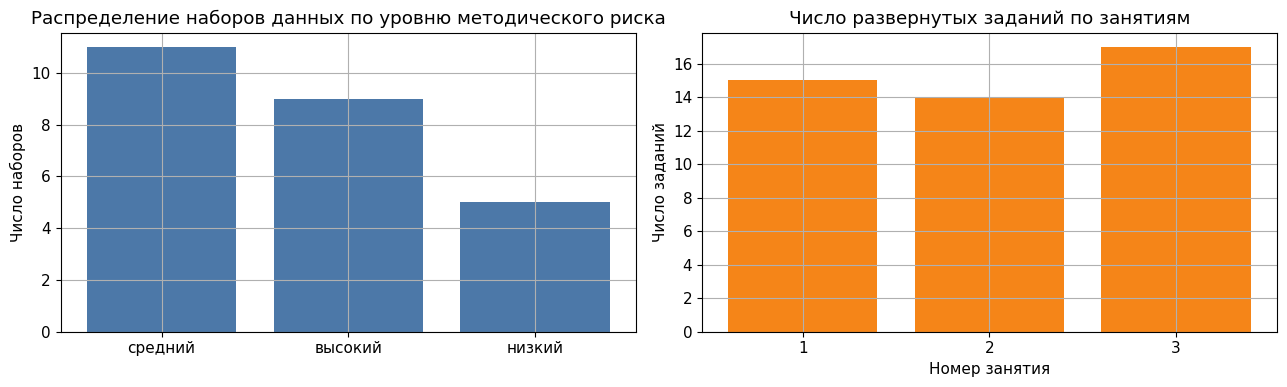

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

risk_counts = dataset_catalog["risk_level"].value_counts()
axes[0].bar(risk_counts.index, risk_counts.values, color="#4c78a8")
axes[0].set_title("Распределение наборов данных по уровню методического риска")
axes[0].set_ylabel("Число наборов")

lesson_counts = (
    dataset_assignments["lesson"]
    .astype(str)
    .value_counts()
    .sort_index()
)
axes[1].bar(lesson_counts.index, lesson_counts.values, color="#f58518")
axes[1].set_title("Число развернутых заданий по занятиям")
axes[1].set_xlabel("Номер занятия")
axes[1].set_ylabel("Число заданий")

plt.tight_layout()
plt.show()


In [29]:
lesson_assignments = dataset_assignments[
    dataset_assignments["lesson"].astype(str) == "3"
].copy()

lesson_assignments[
    [
        "assignment_id",
        "assignment_title",
        "implementation_status",
        "dataset_structure",
        "minimum_working_subset",
        "target_rule",
        "split_rule",
        "theory_block",
        "practice_block",
        "recommended_visualizations",
        "expected_artifacts",
        "control_questions",
        "success_criteria",
        "risk_note",
    ]
]


,assignment_id,assignment_title,implementation_status,dataset_structure,minimum_working_subset,target_rule,split_rule,theory_block,practice_block,recommended_visualizations,expected_artifacts,control_questions,success_criteria,risk_note
2,zenodo_motor_temperature_classification,Классификация режимов: ElectricMotorTemperature,external_notebook_ready,"Объект: электродвигатель, представленный многомерными временными рядами (multivariate time series). Формат данных: T...",Использовать компактный CSV из `data/processed/external`; при чтении исходного .ts-файла сохранять profile_id и не п...,"Класс: 1, если целевая температура ниже заранее заданного учебного предела; 0, если предел превышен.",Разбивать по profile_id или по временным блокам; случайное перемешивание соседних фрагментов не применять.,Теоретический блок должен объяснить классификацию (classification) как задачу отнесения наблюдения к одному из заран...,"Практический блок включает формирование целевой переменной, проверку распределения классов и исключение признаков с ...",1. Столбчатая диаграмма распределения классов. 2. Диаграмма рассеяния двух ключевых признаков с цветом класса. 3. Ма...,"Распределение классов, график признаков с раскраской по классам, матрица ошибок, таблица метрик, визуализация дерева...",Как сформирована целевая переменная? Какой тип ошибки наиболее опасен инженерно? Какие признаки могут привести к уте...,"Зачет: распределение классов, метрики по опасному классу, матрица ошибок, 2-3 правила дерева.",физические имена каналов в архиве не заданы; требуется групповое разбиение по profile_id
5,pmsm_inverter_fault_zenodo_classification,Классификация режимов: Comprehensive Dataset for Fault Detection and Diagnosis in Inverter-Driven PMSM Systems,external_notebook_ready,"Объект: PMSM-инвертор, лабораторная диагностика. Формат данных: CSV / zip. Размер или масштаб: компактный архив окол...","Для базовой работы использовать полный файл, если он загружается менее чем за 2-3 минуты.",Класс: сформировать бинарную метку по заранее заданному учебному порогу.,Использовать фиксированное train/test-разбиение 75/25 с random_state; для дисбаланса классов применять stratify.,Теоретический блок должен объяснить классификацию (classification) как задачу отнесения наблюдения к одному из заран...,"Практический блок включает формирование целевой переменной, проверку распределения классов и исключение признаков с ...",1. Столбчатая диаграмма распределения классов. 2. Диаграмма рассеяния двух ключевых признаков с цветом класса. 3. Ма...,"Распределение классов, график признаков с раскраской по классам, матрица ошибок, таблица метрик, визуализация дерева...",Как сформирована целевая переменная? Какой тип ошибки наиболее опасен инженерно? Какие признаки могут привести к уте...,"Зачет: распределение классов, метрики по опасному классу, матрица ошибок, 2-3 правила дерева.","исходная постановка ближе к диагностике, чем к расчету КПД"
14,pmsm_foc_mendeley_classification,Классификация режимов: PMSM_FOC dataset,methodology_only,"Объект: PMSM с Field Oriented Control. Формат данных: MAT, JPG. Размер или масштаб: размер на карточке не указан. До...",Использовать малое подмножество: не более 500 окон сигналов с агрегированными признаками.,Класс: сформировать бинарную метку по заранее заданному учебному порогу.,Использовать фиксированное train/test-разбиение 75/25 с random_state; для дисбаланса классов применять stratify.,Теоретический блок должен объяснить классификацию (classification) как задачу отнесения наблюдения к одному из заран...,"Практический блок включает формирование целевой переменной, проверку распределения классов и исключение признаков с ...",1. Столбчатая диаграмма распределения классов. 2. Диаграмма рассеяния двух ключевых признаков с цветом класса. 3. Ма...,"Распределение классов, график признаков с раскраской по классам, матрица ошибок, таблица метрик, визуализация дерева...",Как сформирована целевая переменная? Какой тип ошибки наиболее опасен инженерно? Какие призна

## Индивидуальное расширенное задание

Выберите один набор данных из таблицы выше и выполните соответствующее
развернутое задание. Если источник требует учетной записи, крупной загрузки
или специального формата файлов, допускается использовать малое заранее
подготовленное подмножество. В отчете обязательно укажите, была ли работа
выполнена на полном наборе данных, подмножестве или только на методическом
описании источника.


## Методический комментарий для преподавателя

При фиксированном разбиении данных ожидаемые ориентиры для `max_depth=3`:

1. строгая модель имеет долю правильных ответов (accuracy) около 0.93;
2. полнота для класса "недопустимый режим" около 0.81, F1-мера около 0.88;
3. ожидаемая матрица ошибок строгой модели близка к `[[25, 6], [1, 73]]`;
4. наиболее значимые признаки строгого дерева обычно включают `voltage_v`,
   `temperature_c`, `speed_rpm` и `current_a`;
5. опасная ошибка - недопустимый режим, ошибочно отнесенный к допустимым.

Важно проверить, что студенты не включили в признаки `mode_label`,
`violation_count`, `current_margin_a`, `temperature_margin_c`,
`speed_margin_rpm`, признаки причин нарушения, `efficiency` или
`output_power_w`.


In [30]:
print("Матрица ошибок:")
print(cm)
print("\nВажность признаков:")
print(feature_importance.round(3))


Матрица ошибок:
[[25  6]
 [ 1 73]]

Важность признаков:
voltage_v         0.313
temperature_c     0.278
speed_rpm         0.191
current_a         0.168
torque_nm         0.050
ambient_temp_c    0.000
dtype: float64
